**R0**

Columnas detectadas: ['Run', 'X', 'Y']
------------------------------
Resultados guardados en: C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R0_act.csv
------------------------------
   Run     X         Y         R0
0    1  4.00 -1.120000  19.964714
1    2 -0.60  4.000000  34.450170
2    3 -1.16 -2.240000  20.377027
3    4 -0.52  0.597419  38.732879
4    5  1.12 -4.000000  19.964714


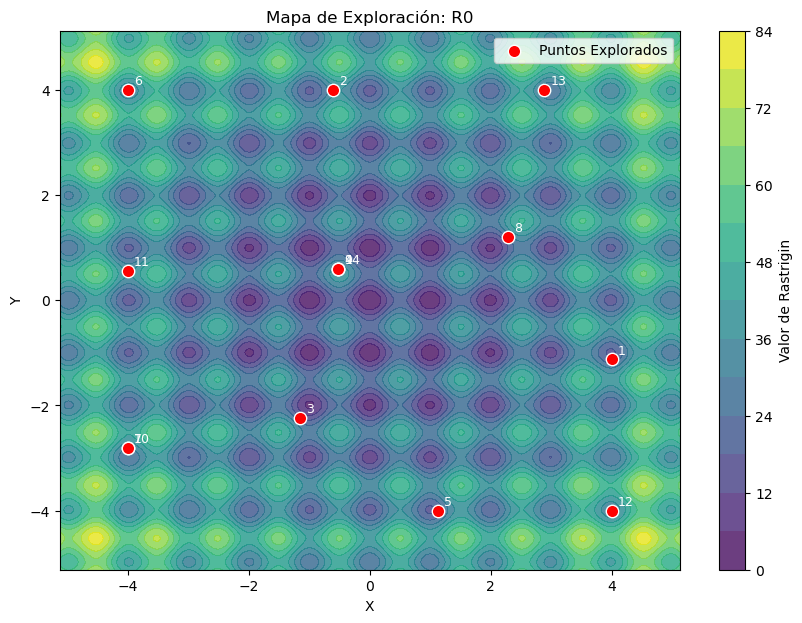

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R0_plot.jpg


In [39]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt


# Definimos la ruta de entrada
input_file = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R0.csv"
# Definimos la ruta de salida (en la misma carpeta)
output_file = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R0_act.csv"
output_plot = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R0_plot.jpg"

# Usamos 'r' al principio de la ruta para que Windows no confunda las \ con comandos

    
try:

    # 1. Cargar datos # Leemos el archivo detectando automáticamente el separador (coma o punto y coma)
    df = pd.read_csv(input_file, sep=None, engine='python')

    # Limpiamos nombres de columnas (quita espacios invisibles como " X" -> "X")
    df.columns = df.columns.str.strip()
    print(f"Columnas detectadas: {list(df.columns)}")


    # 2. Definir la función de Rastrigin 
    def rastrigin(x, y):
        return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
        
    # 3. Extraer valores de la columna 2 (X) y de la columna 3(Y) (Usando .iloc es más seguro si las columnas son la 2 y la 3)
    val_x = df.iloc[:, 1] # iloc[:, 1] es la segunda columna donde estan los valores de X
    val_y = df.iloc[:, 2] # iloc[:, 2] es la tercera columna donde estan los valores de Y

    # 4. Calcular el resultado y guardarlo en la nueva columna 4 (indice 3)
    df['R0'] = rastrigin(val_x, val_y)

    # 5. Guardar el archivo actualizado en el Escritorio
    df.to_csv(output_file, index=False)

    print("-" * 30)
    print(f"Resultados guardados en: {output_file}")
    print("-" * 30)
    print(df.head()) # Mostrar los primeros resultados para verificar

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {input_file}")
except Exception as e: 
    print(f"Ocurrió un error: {e}")



# 1. Crear el fondo de la función
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (20 + (X_mesh**2 - 10*cos(2*math.pi*X_mesh)) + (Y_mesh**2 - 10*cos(2*math.pi*Y_mesh)))
        
# 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')

#afegir les linies de contorn blanques dels punts
#plt.contour(X_mesh, Y_mesh, Z_mesh, levels=15, colors='white', linewidths=0.5, alpha=0.8)

# 3. Dibujar TUS puntos (usando el df que ya tienes en memoria)
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
    plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

plt.title("Mapa de Exploración: R0")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{output_plot}")

**R1**

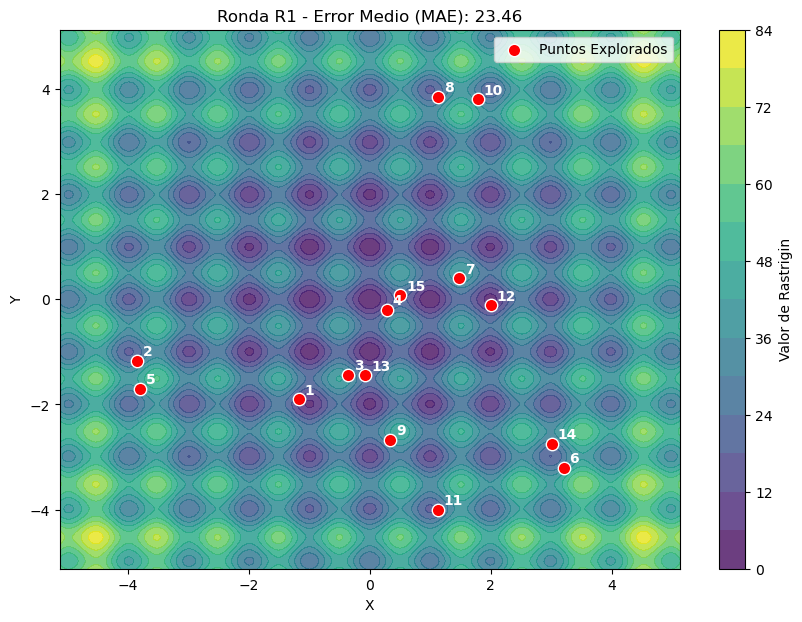

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R1_Grafico.jpg


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R1.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
min_x, min_y = (0, 0)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
val_x, val_y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = rastrigin(val_x, val_y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((val_x - min_x)**2 + (val_y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = rastrigin(X_mesh, Y_mesh)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R1 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{plot_path}")



**R2**

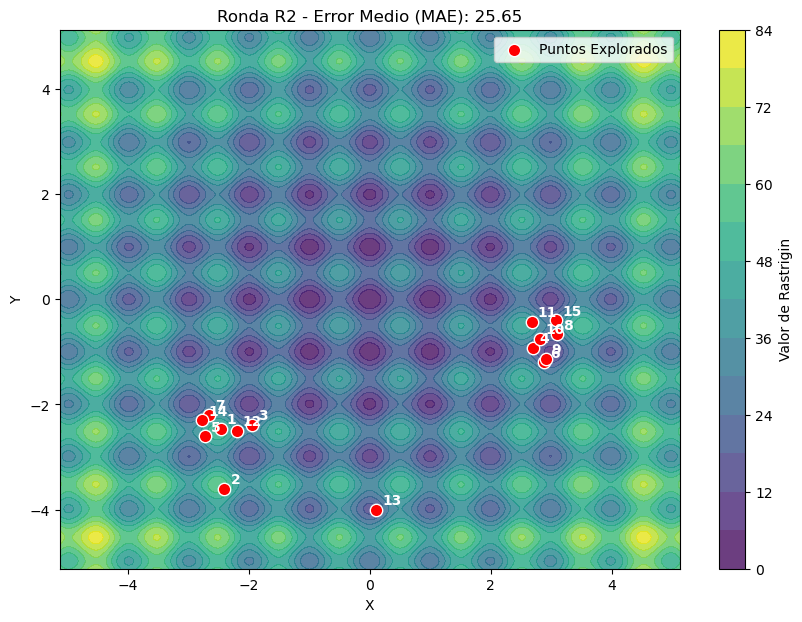

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R2_Grafico.jpg


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R2.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
min_x, min_y = (0, 0)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
val_x, val_y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = rastrigin(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = rastrigin(X_mesh, Y_mesh)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R2 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")



**R3**

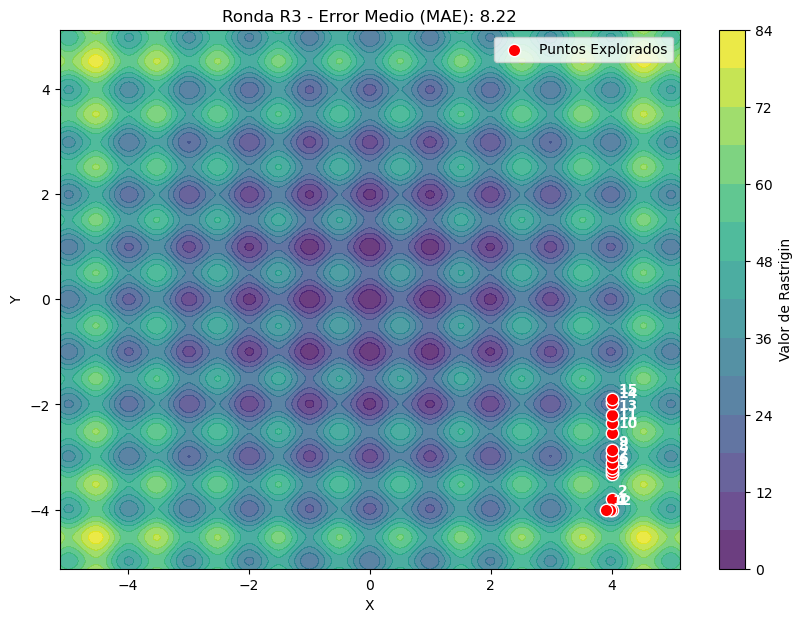

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R3_Grafico.jpg


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R3.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
min_x, min_y = (0, 0)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
val_x, val_y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = rastrigin(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = rastrigin(X_mesh, Y_mesh)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R3 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")



**R4**

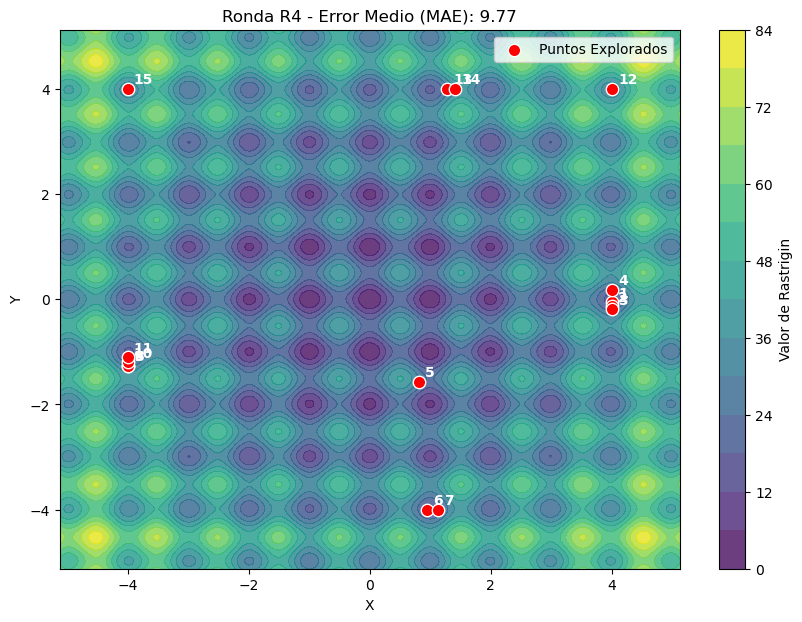

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R4_Grafico.jpg


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R4.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
min_x, min_y = (0, 0)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
val_x, val_y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = rastrigin(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = rastrigin(X_mesh, Y_mesh)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R4 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")



**R5**

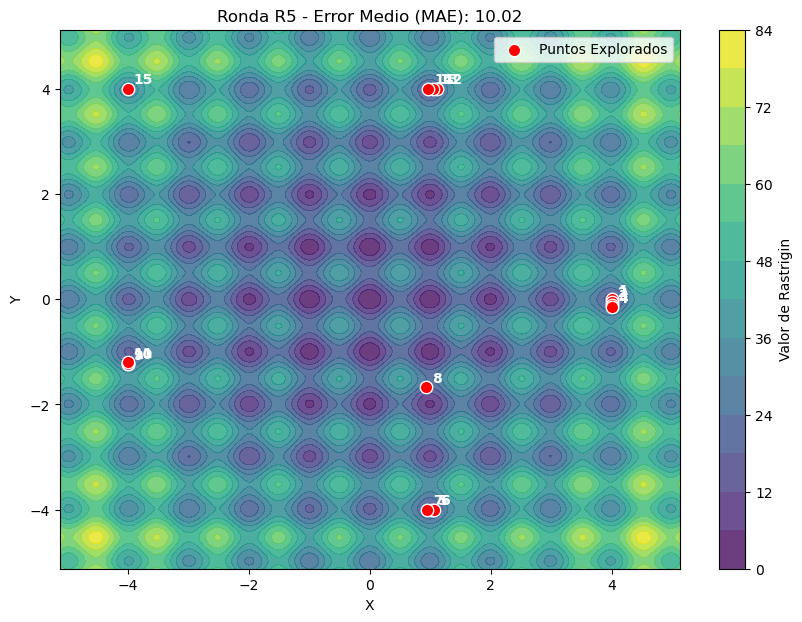

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R5_Grafico.jpg


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R5.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
min_x, min_y = (0, 0)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
val_x, val_y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = rastrigin(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = rastrigin(X_mesh, Y_mesh)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R5 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")



**R6**

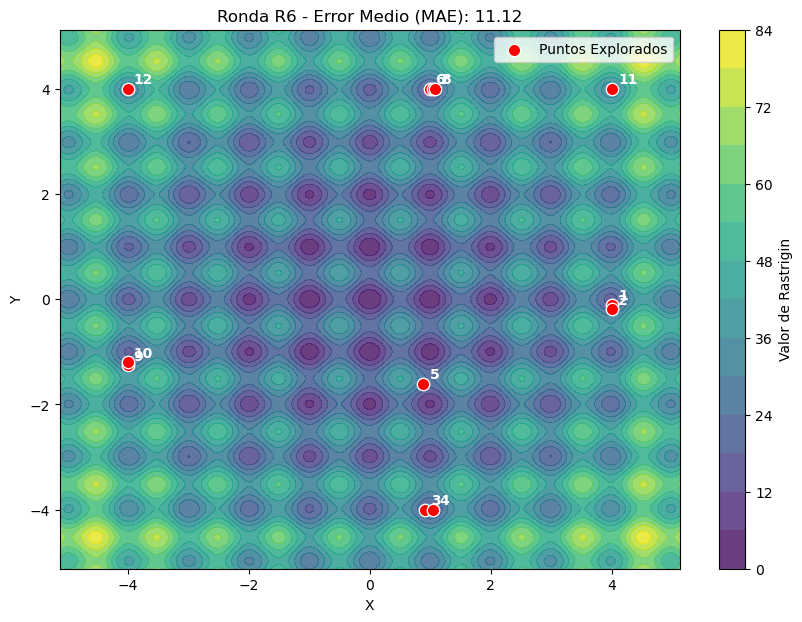

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R6_Grafico.jpg


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R6.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
min_x, min_y = (0, 0)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
val_x, val_y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = rastrigin(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = rastrigin(X_mesh, Y_mesh)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R6 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")



**R7**

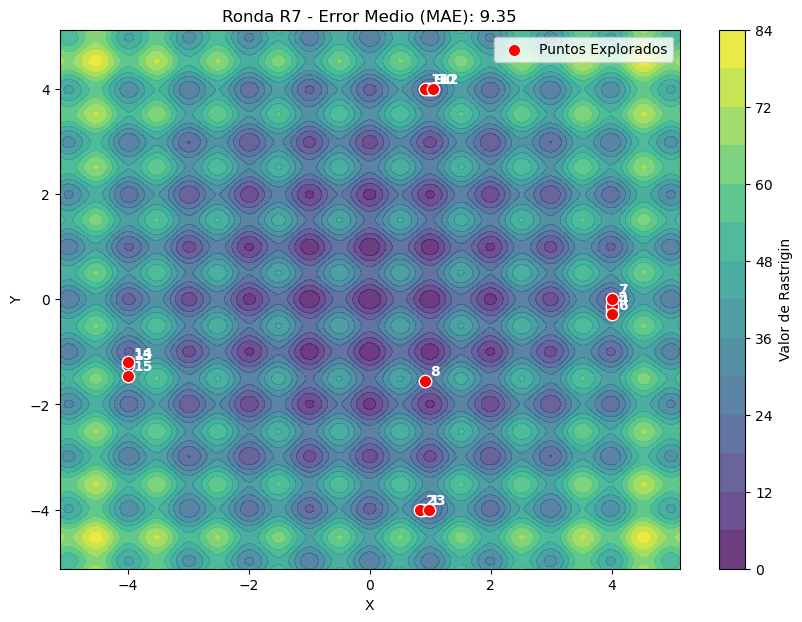

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R7_Grafico.jpg


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Rastrigin\Rastrigin_R7.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))
    
min_x, min_y = (0, 0)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
val_x, val_y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = rastrigin(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-5.12, 5.12, 500)
y_range = np.linspace(-5.12, 5.12, 500)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = rastrigin(X_mesh, Y_mesh)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Rastrigin')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R7 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{plot_path}")



**TAULA RESUM**

In [53]:

import pandas as pd
import numpy as np
import os

# 1. CONFIGURACIÓ DE RUTES
folder_path = r"C:\Users\Usuario\Desktop\Rastrigin"
rondes = range(0, 8)  # De la R0 a la R7 (ajusta segons necessitis)
resum_dades = []

def rastrigin(x, y):
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)))

# 2. BUCLE PER PROCESSAR CADA RONDA
for r in rondes:
    # Busquem el fitxer corregit (el que ja té els càlculs fets)
    # Si encara no els tens fets, podem fer servir el fitxer base
    file_name = f"Rastrigin_R{r}.csv" 
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        try:
            # Llegir dades (ignorant la fila de 'RESUMEN' si ja la vas afegir)
            df = pd.read_csv(file_path, sep=None, engine='python')
            df.columns = df.columns.str.strip()
            
            # Netegem si hi ha files de text (com la de 'RESUMEN')
            df = df[pd.to_numeric(df.iloc[:, 0], errors='coerce').notnull()]
            
            # Extraure columnes (X és índex 1, Y és índex 2)
            val_x = pd.to_numeric(df.iloc[:, 1])
            val_y = pd.to_numeric(df.iloc[:, 2])
            
            # Càlculs per a la taula resum
            distancia_min = np.sqrt(val_x**2 + val_y**2).mean() # Distància mitjana al (0,0)
            valor_funcio = rastrigin(val_x, val_y).mean()        # Valor mitjà de Rastrigin
            
            # El MAE depèn de si tens la columna de predicció. 
            # Si no existeix, posem 0 o el calculem si tens la dada.
            mae_val = 0
            if 'MAE' in df.columns:
                mae_val = pd.to_numeric(df['MAE']).mean()

            # Guardar a la llista
            resum_dades.append({
                'RONDES': r,
                'Distància': round(distancia_min, 2),
                'MAE': round(mae_val, 2),
                f'R{r} FUNC': round(valor_funcio, 2)
            })
            
        except Exception as e:
            print(f"Error processant R{r}: {e}")

# 3. CREAR LA TAULA FINAL
df_final = pd.DataFrame(resum_dades)

# 4. MOSTRAR I GUARDAR
print("\n--- TAULA RESUM DE RONDES ---")
print(df_final.to_string(index=False))

output_resum = os.path.join(folder_path, "Resum_Rondes_Rastrigin.csv")
df_final.to_csv(output_resum, index=False)
print(f"\nTaula guardada a: {output_resum}")


--- TAULA RESUM DE RONDES ---
 RONDES  Distància  MAE  R0 FUNC  R1 FUNC  R2 FUNC  R3 FUNC  R4 FUNC  R5 FUNC  R6 FUNC  R7 FUNC
      0       3.56    0    30.32      NaN      NaN      NaN      NaN      NaN      NaN      NaN
      1       2.76    0      NaN     26.4      NaN      NaN      NaN      NaN      NaN      NaN
      2       3.33    0      NaN      NaN    32.08      NaN      NaN      NaN      NaN      NaN
      3       5.04    0      NaN      NaN      NaN    31.71      NaN      NaN      NaN      NaN
      4       4.17    0      NaN      NaN      NaN      NaN     25.1      NaN      NaN      NaN
      5       4.06    0      NaN      NaN      NaN      NaN      NaN     20.5      NaN      NaN
      6       4.18    0      NaN      NaN      NaN      NaN      NaN      NaN    22.49      NaN
      7       3.95    0      NaN      NaN      NaN      NaN      NaN      NaN      NaN    21.88

Taula guardada a: C:\Users\Usuario\Desktop\Rastrigin\Resum_Rondes_Rastrigin.csv
